# Prophet Model — Campus Waste Forecasting

This notebook trains a Prophet model to forecast daily waste generation per canteen section. Prophet is a time-series forecasting library developed by Meta that handles seasonality and holidays automatically. It works well with daily data that exhibits weekly and yearly patterns.

## 0. Imports

All required libraries are imported here. Prophet is the main forecasting library. Pandas and NumPy handle data manipulation. Scikit-learn provides evaluation metrics.

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

Importing plotly failed. Interactive plots will not work.


## 1. Hyperparameters

All tunable parameters are defined in this cell for easy modification. The forecast horizon is 7 days. The test size determines how many days are held out for final evaluation.

In [2]:
# ── Forecast Settings ─────────────────────────────────────────────────────────
FORECAST_HORIZON = 7          # Days to predict ahead
TEST_DAYS = 30                # Days held out for final test evaluation

# ── Cross-Validation Settings ─────────────────────────────────────────────────
CV_INITIAL = '180 days'       # Initial training period for CV
CV_PERIOD = '30 days'         # Spacing between cutoff dates
CV_HORIZON = '7 days'         # Forecast horizon for CV (matches FORECAST_HORIZON)

# ── Hyperparameter Grid for Tuning ────────────────────────────────────────────
PARAM_GRID = {
    'changepoint_prior_scale': [0.05, 0.1, 0.2],
    'seasonality_prior_scale': [1.0, 5.0, 10.0],
    'holidays_prior_scale': [1.0, 5.0, 10.0],
}

# ── Fixed Prophet Parameters (not tuned) ──────────────────────────────────────
FIXED_PARAMS = {
    'seasonality_mode': 'multiplicative',  # 'additive' or 'multiplicative'
    'yearly_seasonality': True,            # Enable yearly patterns
    'weekly_seasonality': True,            # Enable weekly patterns
    'daily_seasonality': False,            # Disable (data is already daily)
}

# ── Regressors to Include ─────────────────────────────────────────────────────
USE_REGRESSORS = True
REGRESSOR_COLS = ['Foot_Traffic', 'is_holiday', 'is_special_day']

# ── Data Path ─────────────────────────────────────────────────────────────────
DATA_PATH = 'data/waste_features_full.csv'

# Calculate total grid combinations
n_combinations = 1
for values in PARAM_GRID.values():
    n_combinations *= len(values)
print(f"Hyperparameters loaded. Grid search will test {n_combinations} combinations per section.")

Hyperparameters loaded. Grid search will test 27 combinations per section.


## 2. Helper Functions

Modular functions for data preparation, model training, and evaluation. This keeps the main code clean and reusable.

In [3]:
def load_data(path: str) -> pd.DataFrame:
    """Load the feature-engineered dataset and parse dates."""
    df = pd.read_csv(path)
    df['date'] = pd.to_datetime(df['date'])
    return df


def prepare_prophet_data(df: pd.DataFrame, section: str, regressor_cols: list = None) -> pd.DataFrame:
    """
    Prepare data for Prophet. Prophet requires columns named 'ds' (date) and 'y' (target).
    
    Args:
        df: Full dataset with all sections
        section: Canteen section to filter (A, B, C, or D)
        regressor_cols: Optional list of regressor column names
    
    Returns:
        DataFrame with ds, y, and optional regressors
    """
    section_df = df[df['Canteen_Section'] == section].copy()
    section_df = section_df.sort_values('date').reset_index(drop=True)
    
    prophet_df = pd.DataFrame({
        'ds': section_df['date'],
        'y': section_df['Waste_Weight_kg']
    })
    
    if regressor_cols:
        for col in regressor_cols:
            if col in section_df.columns:
                prophet_df[col] = section_df[col].values
    
    return prophet_df


def temporal_split(df: pd.DataFrame, test_days: int, val_days: int = 0):
    """
    Split data temporally to avoid data leakage. The most recent days become the test set.
    
    Args:
        df: DataFrame sorted by date
        test_days: Number of days for the test set
        val_days: Number of days for validation (before test)
    
    Returns:
        train, val (or None), test DataFrames
    """
    n = len(df)
    test_start = n - test_days
    val_start = test_start - val_days if val_days > 0 else test_start
    
    train = df.iloc[:val_start].copy()
    val = df.iloc[val_start:test_start].copy() if val_days > 0 else None
    test = df.iloc[test_start:].copy()
    
    return train, val, test


def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """
    Compute evaluation metrics for regression.
    
    Metrics:
        - RMSE: Root Mean Squared Error (penalizes large errors)
        - MAE: Mean Absolute Error (average absolute difference)
        - MAPE: Mean Absolute Percentage Error (scale-independent)
        - R2: Coefficient of determination (explained variance)
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    # MAPE: avoid division by zero
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    
    return {'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R2': r2}


def baseline_moving_average(train: pd.DataFrame, test: pd.DataFrame, window: int = 7) -> np.ndarray:
    """
    Compute a simple moving average baseline. The forecast for each test day is the average
    of the last 'window' days from the training set (for the first test day) or the rolling
    window including previous test actuals.
    """
    all_y = pd.concat([train['y'], test['y']], ignore_index=True)
    train_len = len(train)
    
    predictions = []
    for i in range(len(test)):
        idx = train_len + i
        start_idx = max(0, idx - window)
        predictions.append(all_y.iloc[start_idx:idx].mean())
    
    return np.array(predictions)


def print_metrics_comparison(baseline_metrics: dict, model_metrics: dict):
    """Print a formatted comparison of baseline vs model metrics."""
    print("\n" + "=" * 55)
    print(f"{'Metric':<10} {'Baseline':>12} {'Prophet':>12} {'Improvement':>15}")
    print("=" * 55)
    
    for metric in ['RMSE', 'MAE', 'MAPE', 'R2']:
        base_val = baseline_metrics[metric]
        model_val = model_metrics[metric]
        
        if metric == 'R2':
            improvement = model_val - base_val
            imp_str = f"+{improvement:.4f}" if improvement > 0 else f"{improvement:.4f}"
        else:
            improvement = ((base_val - model_val) / base_val) * 100 if base_val != 0 else 0
            imp_str = f"{improvement:+.1f}%"
        
        print(f"{metric:<10} {base_val:>12.4f} {model_val:>12.4f} {imp_str:>15}")
    
    print("=" * 55)


def tune_prophet_hyperparameters(train_df: pd.DataFrame, param_grid: dict, fixed_params: dict,
                                  regressor_cols: list = None, cv_initial: str = '180 days',
                                  cv_period: str = '30 days', cv_horizon: str = '7 days') -> dict:
    """
    Perform grid search over Prophet hyperparameters using cross-validation.
    
    Args:
        train_df: Training data with 'ds', 'y', and optional regressors
        param_grid: Dictionary of parameter names to lists of values to try
        fixed_params: Fixed parameters that don't change during tuning
        regressor_cols: Optional list of regressor column names
        cv_initial: Initial training period for cross-validation
        cv_period: Spacing between cutoff dates
        cv_horizon: Forecast horizon for each fold
    
    Returns:
        Dictionary with best parameters and CV results
    """
    from itertools import product
    
    # Generate all parameter combinations
    param_names = list(param_grid.keys())
    param_values = list(param_grid.values())
    all_combinations = list(product(*param_values))
    
    best_rmse = float('inf')
    best_params = None
    all_results = []
    
    print(f"Testing {len(all_combinations)} parameter combinations...")
    
    for i, combo in enumerate(all_combinations, 1):
        # Build parameter dict for this combination
        current_params = dict(zip(param_names, combo))
        full_params = {**fixed_params, **current_params}
        
        try:
            # Create and configure model
            model = Prophet(**full_params)
            
            # Add regressors if specified
            if regressor_cols:
                for col in regressor_cols:
                    if col in train_df.columns:
                        model.add_regressor(col)
            
            # Fit model
            model.fit(train_df)
            
            # Cross-validation
            cv_results = cross_validation(
                model,
                initial=cv_initial,
                period=cv_period,
                horizon=cv_horizon,
                parallel='threads'
            )
            
            # Compute metrics
            metrics = performance_metrics(cv_results)
            mean_rmse = metrics['rmse'].mean()
            mean_mae = metrics['mae'].mean()
            mean_mape = metrics['mape'].mean() * 100  # Convert to percentage
            
            all_results.append({
                'params': current_params,
                'rmse': mean_rmse,
                'mae': mean_mae,
                'mape': mean_mape
            })
            
            # Track best
            if mean_rmse < best_rmse:
                best_rmse = mean_rmse
                best_params = current_params
            
            if i % 9 == 0 or i == len(all_combinations):  # Progress update
                print(f"  [{i}/{len(all_combinations)}] Best RMSE so far: {best_rmse:.4f}")
                
        except Exception as e:
            print(f"  Combination {i} failed: {str(e)[:50]}")
            continue
    
    return {
        'best_params': best_params,
        'best_rmse': best_rmse,
        'all_results': all_results
    }

## 3. Load and Explore Data

In [4]:
df = load_data(DATA_PATH)

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Sections: {sorted(df['Canteen_Section'].unique())}")
print(f"\nColumns: {list(df.columns)}")
df.head()

Dataset shape: (15431, 10)
Date range: 2015-01-01 to 2025-08-10
Sections: ['A', 'B', 'C', 'D']

Columns: ['date', 'Canteen_Section', 'Waste_Weight_kg', 'Foot_Traffic', 'is_holiday', 'is_special_day', 'is_weekend', 'weekday', 'month', 'week_of_year']


,date,Canteen_Section,Waste_Weight_kg,Foot_Traffic,is_holiday,is_special_day,is_weekend,weekday,month,week_of_year
0,2015-01-01,A,5.06,106.666667,1,1,0,3,1,1
1,2015-01-02,A,8.20,105.000000,0,0,0,4,1,1
2,2015-01-03,A,18.35,70.000000,0,1,1,5,1,1
3,2015-01-04,A,3.72,70.000000,0,1,1,6,1,1
4,2015-01-05,A,22.08,88.571429,0,0,0,0,1,2


## 4. Train and Evaluate Prophet (All Sections)

We train a separate Prophet model for each canteen section. This approach captures section-specific patterns in waste generation. The loop below processes each section and stores results for comparison.

In [5]:
sections = sorted(df['Canteen_Section'].unique())
results = {}
tuning_results = {}  # Store hyperparameter tuning info

for section in sections:
    print(f"\n{'='*70}")
    print(f"SECTION {section}")
    print(f"{'='*70}")
    
    # Prepare data
    regressor_cols = REGRESSOR_COLS if USE_REGRESSORS else None
    prophet_df = prepare_prophet_data(df, section, regressor_cols)
    
    print(f"Total observations: {len(prophet_df)}")
    
    # Temporal split (no validation split needed - CV handles it)
    train, _, test = temporal_split(prophet_df, TEST_DAYS, val_days=0)
    print(f"Train: {len(train)} | Test: {len(test)}")
    
    # ────────────────────────────────────────────────────────────────────────
    # Step 1: Hyperparameter Tuning via Cross-Validation
    # ────────────────────────────────────────────────────────────────────────
    print(f"\n--- Hyperparameter Tuning ---")
    
    tuning_result = tune_prophet_hyperparameters(
        train_df=train,
        param_grid=PARAM_GRID,
        fixed_params=FIXED_PARAMS,
        regressor_cols=regressor_cols,
        cv_initial=CV_INITIAL,
        cv_period=CV_PERIOD,
        cv_horizon=CV_HORIZON
    )
    
    tuning_results[section] = tuning_result
    best_params = tuning_result['best_params']
    
    print(f"\nBest Parameters for Section {section}:")
    for param, value in best_params.items():
        print(f"  {param}: {value}")
    print(f"  CV RMSE: {tuning_result['best_rmse']:.4f}")
    
    # ────────────────────────────────────────────────────────────────────────
    # Step 2: Baseline Calculation
    # ────────────────────────────────────────────────────────────────────────
    baseline_pred = baseline_moving_average(train, test, window=7)
    baseline_metrics = compute_metrics(test['y'].values, baseline_pred)
    print(f"\nBaseline (7-day MA): RMSE={baseline_metrics['RMSE']:.4f}, MAE={baseline_metrics['MAE']:.4f}")
    
    # ────────────────────────────────────────────────────────────────────────
    # Step 3: Train Final Model with Best Parameters
    # ────────────────────────────────────────────────────────────────────────
    print(f"\n--- Training Final Model with Tuned Parameters ---")
    
    final_params = {**FIXED_PARAMS, **best_params}
    model = Prophet(**final_params)
    
    # Add regressors if enabled
    if USE_REGRESSORS and regressor_cols:
        for col in regressor_cols:
            if col in train.columns:
                model.add_regressor(col)
    
    model.fit(train)
    
    # ────────────────────────────────────────────────────────────────────────
    # Step 4: Predict on Test Set and Evaluate
    # ────────────────────────────────────────────────────────────────────────
    forecast = model.predict(test)
    prophet_pred = forecast['yhat'].values
    
    prophet_metrics = compute_metrics(test['y'].values, prophet_pred)
    
    print_metrics_comparison(baseline_metrics, prophet_metrics)
    
    # Store results
    results[section] = {
        'model': model,
        'best_params': best_params,
        'train': train,
        'test': test,
        'predictions': prophet_pred,
        'baseline_pred': baseline_pred,
        'baseline_metrics': baseline_metrics,
        'prophet_metrics': prophet_metrics,
        'cv_rmse': tuning_result['best_rmse']
    }


SECTION A
Total observations: 3848
Train: 3818 | Test: 30

--- Hyperparameter Tuning ---
Testing 27 parameter combinations...


12:28:54 - cmdstanpy - INFO - Chain [1] start processing
12:28:54 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.
12:28:55 - cmdstanpy - INFO - Chain [1] start processing
12:28:56 - cmdstanpy - INFO - Chain [1] start processing
12:28:56 - cmdstanpy - INFO - Chain [1] start processing
12:28:56 - cmdstanpy - INFO - Chain [1] start processing
12:28:56 - cmdstanpy - INFO - Chain [1] done processing
12:28:56 - cmdstanpy - INFO - Chain [1] start processing
12:28:56 - cmdstanpy - INFO - Chain [1] start processing
12:28:56 - cmdstanpy - INFO - Chain [1] done processing
12:28:56 - cmdstanpy - INFO - Chain [1] start processing
12:28:56 - cmdstanpy - INFO - Chain [1] start processing
12:28:56 - cmdstanpy - INFO - Chain [1] done processing
12:28:56 - cmdstanpy - INFO - Chain [1] start processing
12:28:56 - cmdstanpy - INFO - Chain [1] start processing
12:28:56 - cmdstanpy - INFO - Chain [1] done 

  [9/27] Best RMSE so far: 5.5751


12:35:17 - cmdstanpy - INFO - Chain [1] start processing
12:35:18 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.
12:35:19 - cmdstanpy - INFO - Chain [1] start processing
12:35:19 - cmdstanpy - INFO - Chain [1] start processing
12:35:19 - cmdstanpy - INFO - Chain [1] start processing
12:35:19 - cmdstanpy - INFO - Chain [1] start processing
12:35:19 - cmdstanpy - INFO - Chain [1] start processing
12:35:19 - cmdstanpy - INFO - Chain [1] start processing
12:35:19 - cmdstanpy - INFO - Chain [1] start processing
12:35:19 - cmdstanpy - INFO - Chain [1] start processing
12:35:19 - cmdstanpy - INFO - Chain [1] start processing
12:35:19 - cmdstanpy - INFO - Chain [1] start processing
12:35:19 - cmdstanpy - INFO - Chain [1] done processing
12:35:19 - cmdstanpy - INFO - Chain [1] done processing
12:35:19 - cmdstanpy - INFO - Chain [1] done processing
12:35:19 - cmdstanpy - INFO - Chain [1] done 

  [18/27] Best RMSE so far: 5.5751


...

  [18/27] Best RMSE so far: 5.6984


13:53:53 - cmdstanpy - INFO - Chain [1] start processing
13:53:53 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.
13:53:55 - cmdstanpy - INFO - Chain [1] start processing
13:53:55 - cmdstanpy - INFO - Chain [1] start processing
13:53:55 - cmdstanpy - INFO - Chain [1] start processing
13:53:55 - cmdstanpy - INFO - Chain [1] start processing
13:53:55 - cmdstanpy - INFO - Chain [1] start processing
13:53:55 - cmdstanpy - INFO - Chain [1] start processing
13:53:55 - cmdstanpy - INFO - Chain [1] start processing
13:53:55 - cmdstanpy - INFO - Chain [1] start processing
13:53:55 - cmdstanpy - INFO - Chain [1] start processing
13:53:55 - cmdstanpy - INFO - Chain [1] start processing
13:53:55 - cmdstanpy - INFO - Chain [1] done processing
13:53:55 - cmdstanpy - INFO - Chain [1] done processing
13:53:55 - cmdstanpy - INFO - Chain [1] done processing
13:53:55 - cmdstanpy - INFO - Chain [1] done 

  [27/27] Best RMSE so far: 5.6984

Best Parameters for Section D:
  changepoint_prior_scale: 0.05
  seasonality_prior_scale: 1.0
  holidays_prior_scale: 10.0
  CV RMSE: 5.6984

Baseline (7-day MA): RMSE=5.0809, MAE=3.9016

--- Training Final Model with Tuned Parameters ---


14:02:23 - cmdstanpy - INFO - Chain [1] start processing
14:02:23 - cmdstanpy - INFO - Chain [1] done processing



Metric         Baseline      Prophet     Improvement
RMSE             5.0809       4.9214           +3.1%
MAE              3.9016       4.0209           -3.1%
MAPE            98.8045     118.7466          -20.2%
R2              -0.2488      -0.1717         +0.0772


## 5. Visualize Forecasts

Plot actual vs predicted values for each section. The blue line shows actual waste, orange shows Prophet predictions, and green dashed shows the baseline.

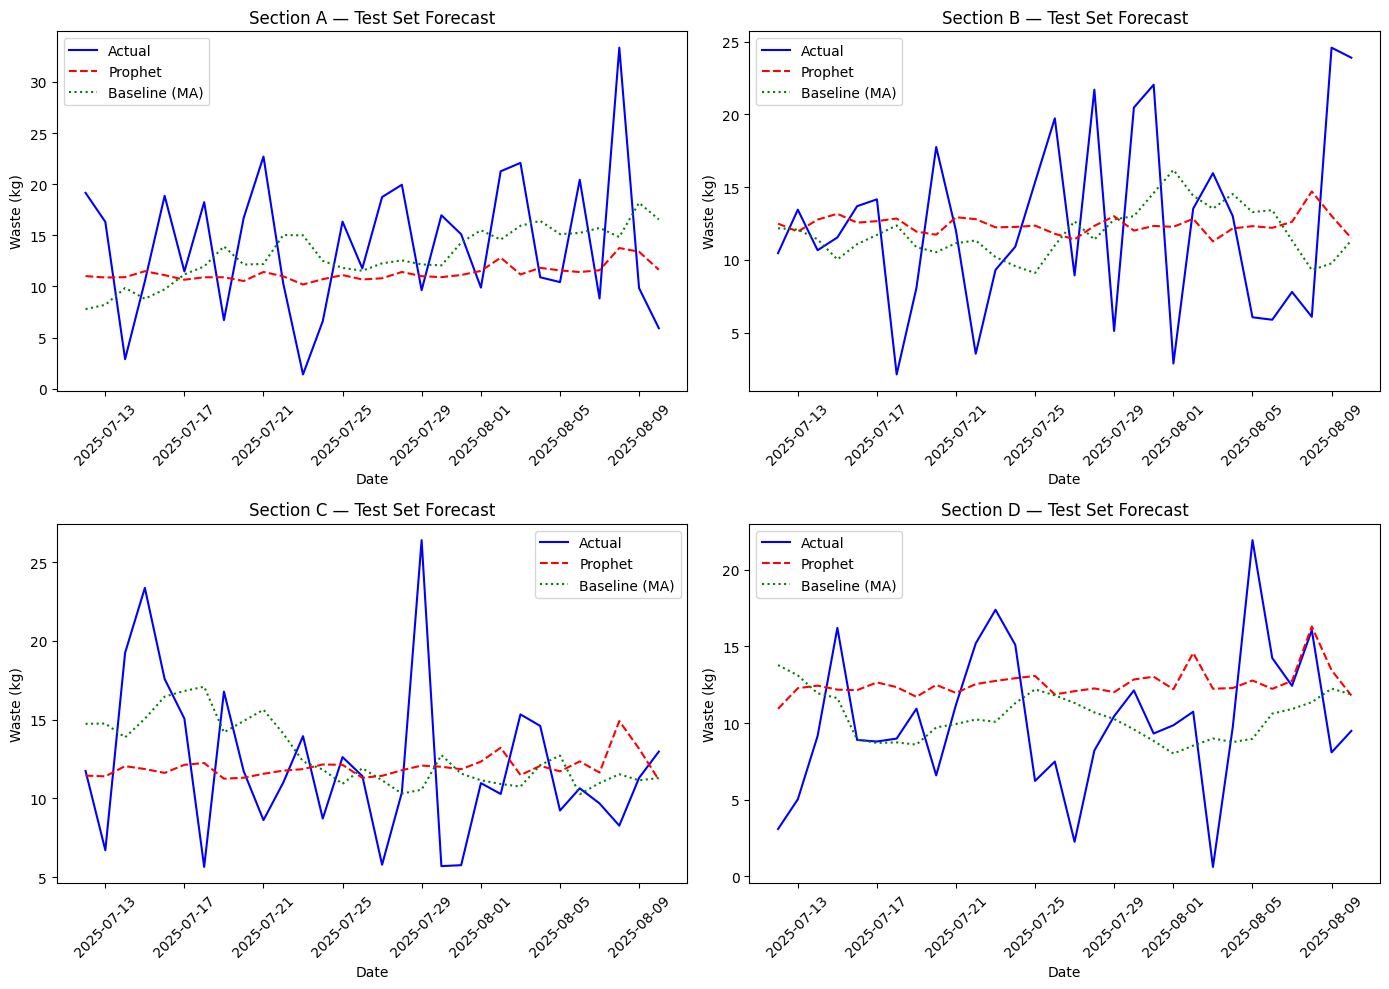

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, section in enumerate(sections):
    ax = axes[idx]
    res = results[section]
    
    test_dates = res['test']['ds']
    actual = res['test']['y'].values
    
    ax.plot(test_dates, actual, 'b-', label='Actual', linewidth=1.5)
    ax.plot(test_dates, res['predictions'], 'r--', label='Prophet', linewidth=1.5)
    ax.plot(test_dates, res['baseline_pred'], 'g:', label='Baseline (MA)', linewidth=1.5)
    
    ax.set_title(f"Section {section} — Test Set Forecast")
    ax.set_xlabel('Date')
    ax.set_ylabel('Waste (kg)')
    ax.legend()
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 6. Seven-Day Ahead Forecast

Generate a 7-day forecast starting from the last date in the dataset. This demonstrates the primary use case: predicting waste for the upcoming week.

In [7]:
def forecast_7_days(model, last_date: pd.Timestamp, regressor_cols: list = None, 
                    regressor_defaults: dict = None):
    """
    Generate a 7-day ahead forecast.
    
    Args:
        model: Trained Prophet model
        last_date: Last date in the training data
        regressor_cols: List of regressor column names
        regressor_defaults: Default values for regressors (if unknown for future)
    
    Returns:
        DataFrame with date, predicted waste, and confidence intervals
    """
    future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=7, freq='D')
    future_df = pd.DataFrame({'ds': future_dates})
    
    # Add regressors with default values
    if regressor_cols and regressor_defaults:
        for col in regressor_cols:
            future_df[col] = regressor_defaults.get(col, 0)
    
    forecast = model.predict(future_df)
    
    result = pd.DataFrame({
        'date': forecast['ds'],
        'predicted_waste_kg': forecast['yhat'],
        'lower_bound': forecast['yhat_lower'],
        'upper_bound': forecast['yhat_upper']
    })
    
    return result

In [8]:
# Generate 7-day forecast for each section
print("7-Day Ahead Forecast (from last date in data)")
print("=" * 70)

# Default regressor values for future dates (adjust based on expected conditions)
regressor_defaults = {
    'Foot_Traffic': df['Foot_Traffic'].mean(),  # Use historical average
    'is_holiday': 0,                             # Assume no holidays
    'is_special_day': 0                          # Assume normal days
}

forecasts_7day = {}

for section in sections:
    res = results[section]
    last_date = res['test']['ds'].max()
    
    regressor_cols = REGRESSOR_COLS if USE_REGRESSORS else None
    forecast_df = forecast_7_days(res['model'], last_date, regressor_cols, regressor_defaults)
    forecasts_7day[section] = forecast_df
    
    print(f"\nSection {section}:")
    print(forecast_df.to_string(index=False))

7-Day Ahead Forecast (from last date in data)

Section A:
      date  predicted_waste_kg  lower_bound  upper_bound
2025-08-11           12.418827     5.013346    19.264722
2025-08-12           12.011758     5.145121    19.415745
2025-08-13           12.035289     4.944431    19.521815
2025-08-14           12.095984     4.762016    19.647418
2025-08-15           12.072707     5.072878    19.734946
2025-08-16           12.872768     5.500959    20.305129
2025-08-17           12.883756     5.652292    20.523141

Section B:
      date  predicted_waste_kg  lower_bound  upper_bound
2025-08-11           12.014652     4.494687    19.786982
2025-08-12           12.523404     5.585070    20.327474
2025-08-13           11.929627     5.128562    19.561578
2025-08-14           12.034957     4.624620    19.609013
2025-08-15           12.156320     5.138676    19.515538
2025-08-16           12.543835     4.976017    20.118500
2025-08-17           12.143634     5.021247    19.224020

Section C:
      

## 7. Results Summary

Aggregate performance metrics across all sections. This provides an overall view of model effectiveness.

In [9]:
print("\n" + "=" * 90)
print("OVERALL RESULTS SUMMARY")
print("=" * 90)

# Metrics summary
summary_data = []
for section in sections:
    res = results[section]
    summary_data.append({
        'Section': section,
        'CV_RMSE': res['cv_rmse'],
        'Baseline_RMSE': res['baseline_metrics']['RMSE'],
        'Prophet_RMSE': res['prophet_metrics']['RMSE'],
        'Prophet_MAE': res['prophet_metrics']['MAE'],
        'Prophet_R2': res['prophet_metrics']['R2'],
        'RMSE_Improvement_%': ((res['baseline_metrics']['RMSE'] - res['prophet_metrics']['RMSE']) / 
                               res['baseline_metrics']['RMSE'] * 100)
    })

summary_df = pd.DataFrame(summary_data)
print("Performance Metrics:")
print(summary_df.round(4).to_string(index=False))

print(f"\nAverage RMSE Improvement: {summary_df['RMSE_Improvement_%'].mean():.2f}%")
print(f"Average Prophet R2: {summary_df['Prophet_R2'].mean():.4f}")

# Best parameters per section
print("\n" + "=" * 90)
print("TUNED HYPERPARAMETERS PER SECTION")
print("=" * 90)

params_data = []
for section in sections:
    res = results[section]
    params_data.append({
        'Section': section,
        'changepoint_prior_scale': res['best_params']['changepoint_prior_scale'],
        'seasonality_prior_scale': res['best_params']['seasonality_prior_scale'],
        'holidays_prior_scale': res['best_params']['holidays_prior_scale']
    })

params_df = pd.DataFrame(params_data)
print(params_df.to_string(index=False))


OVERALL RESULTS SUMMARY
Performance Metrics:
Section  CV_RMSE  Baseline_RMSE  Prophet_RMSE  Prophet_MAE  Prophet_R2  RMSE_Improvement_%
      A   5.5751         7.5522        7.0394       5.7228     -0.0935              6.7903
      B   5.7919         6.7115        6.4564       5.3162     -0.0790              3.8010
      C   5.8144         5.2145        5.0360       3.8607     -0.0568              3.4228
      D   5.6984         5.0809        4.9214       4.0209     -0.1717              3.1390

Average RMSE Improvement: 4.29%
Average Prophet R2: -0.1002

TUNED HYPERPARAMETERS PER SECTION
Section  changepoint_prior_scale  seasonality_prior_scale  holidays_prior_scale
      A                     0.05                      1.0                   1.0
      B                     0.05                     10.0                  10.0
      C                     0.05                      1.0                   1.0
      D                     0.05                      1.0                  10.0


## 8. Save Model (Optional)

Save trained models for later use. Prophet models can be serialized using Python's pickle module.

In [10]:
import pickle

os.makedirs('models', exist_ok=True)

for section in sections:
    model_path = f'models/prophet_section_{section}.pkl'
    with open(model_path, 'wb') as f:
        pickle.dump(results[section]['model'], f)
    print(f"Saved: {model_path}")

print("\nAll Prophet models saved.")

Saved: models/prophet_section_A.pkl
Saved: models/prophet_section_B.pkl
Saved: models/prophet_section_C.pkl
Saved: models/prophet_section_D.pkl

All Prophet models saved.
